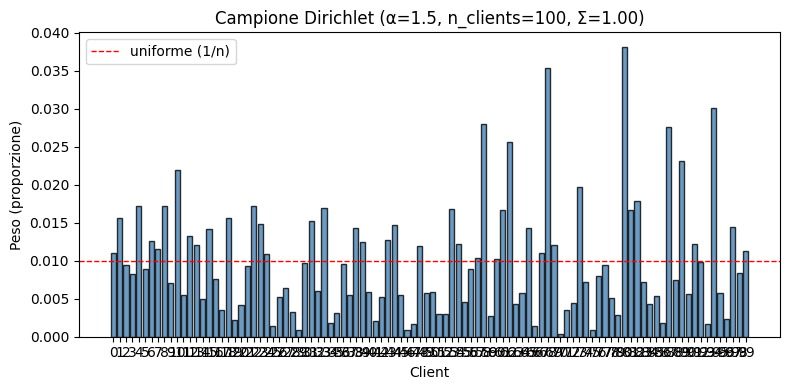

In [16]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n_clients = 100

weights = rng.dirichlet(np.ones(n_clients) * 1.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(n_clients), weights, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Client")
ax.set_ylabel("Peso (proporzione)")
ax.set_title(f"Campione Dirichlet (α=1.5, n_clients={n_clients}, Σ={weights.sum():.2f})")
ax.set_xticks(range(n_clients))
ax.axhline(1 / n_clients, color="red", ls="--", lw=1, label="uniforme (1/n)")
ax.legend()
plt.tight_layout()
plt.show()

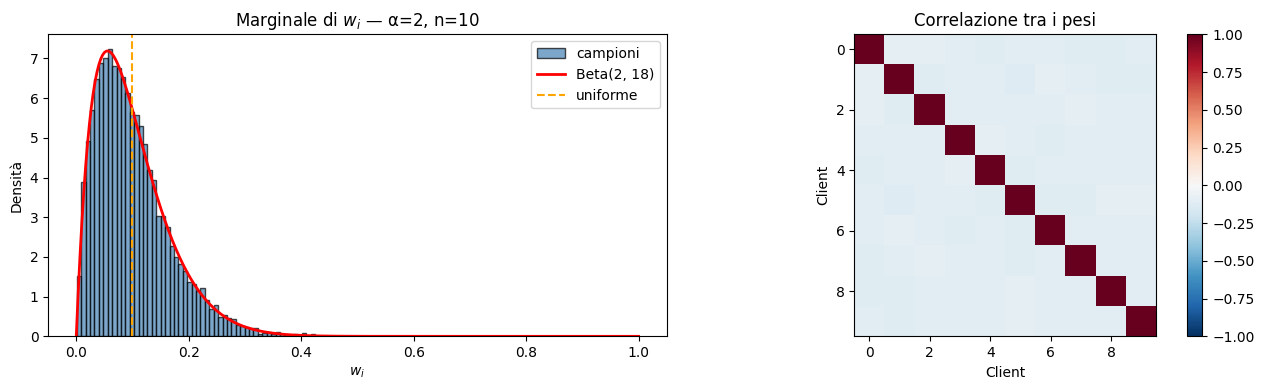

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet

rng = np.random.default_rng(42)
n_clients = 10
alpha = 2
n_samples = 10_000

# Molti campioni dalla Dirichlet
samples = rng.dirichlet(np.ones(n_clients) * alpha, size=n_samples)
# samples.shape -> (10_000, 10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Plot 1: distribuzione marginale di un singolo peso ---
ax = axes[0]
w0 = samples[:, 0]  # marginale di w_0 (tutte le componenti sono identiche per simmetria)
ax.hist(w0, bins=60, density=True, color="steelblue", edgecolor="black", alpha=0.7, label="campioni")

# Densità marginale esatta: Beta(α, (n-1)·α)
x = np.linspace(0, 1, 300)
from scipy.stats import beta as beta_dist
a, b = alpha, (n_clients - 1) * alpha
ax.plot(x, beta_dist.pdf(x, a, b), color="red", lw=2, label=f"Beta({a}, {b:.0f})")
ax.axvline(1 / n_clients, color="orange", ls="--", lw=1.5, label="uniforme")
ax.set_xlabel("$w_i$")
ax.set_ylabel("Densità")
ax.set_title(f"Marginale di $w_i$ — α={alpha}, n={n_clients}")
ax.legend()

# --- Plot 2: heatmap di correlazione tra i pesi ---
ax = axes[1]
corr = np.corrcoef(samples.T)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_title("Correlazione tra i pesi")
ax.set_xlabel("Client")
ax.set_ylabel("Client")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

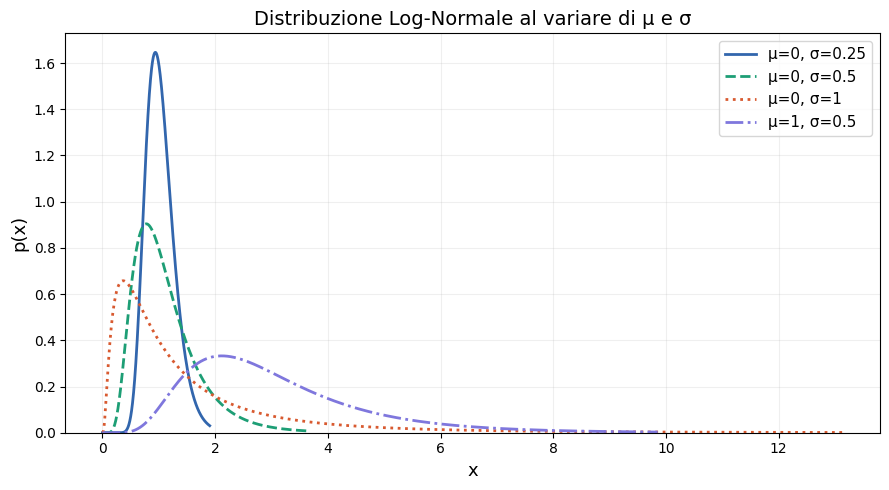

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

mus    = [0, 0, 0,    1  ]  # mu    (media del log)
sigmas = [0.25, 0.5, 1, 0.5]  # sigma (std del log)

colors = ['#3266ad', '#1D9E75', '#D85A30', '#7F77DD']
dashes  = ['-', '--', ':', '-.']

fig, ax = plt.subplots(figsize=(9, 5))

for mu, sigma, c, ls in zip(mus, sigmas, colors, dashes):
    x_max = lognorm.ppf(0.995, s=sigma, scale=np.exp(mu))
    x = np.linspace(1e-4, x_max, 1000)
    pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    ax.plot(x, pdf, color=c, linestyle=ls, lw=2, label=f'μ={mu}, σ={sigma}')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('p(x)', fontsize=13)
ax.set_title('Distribuzione Log-Normale al variare di μ e σ', fontsize=14)
ax.set_ylim(0)
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()